In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
#dataset loaded
df=pd.read_csv('Social_Network_Ads.csv')
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [4]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [5]:
df.isnull().sum()

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [9]:
#separating independent & dependent variables
X=df.iloc[:, :-1].values
y=df.iloc[:, -1].values

In [8]:
#splitting train & test data
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
#scaling features
sc=StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.fit(X_test)
print(X_train_scaled)
print(X_test_scaled)

[[-1.06675246 -0.38634438]
 [ 0.79753468 -1.22993871]
 [ 0.11069205  1.853544  ]
 [ 0.60129393 -0.90995465]
 [ 1.87685881 -1.28811763]
 [-0.57615058  1.44629156]
 [ 0.3069328  -0.53179168]
 [ 0.99377543  0.10817643]
 [-1.16487283  0.45724994]
 [-1.55735433  0.31180264]
 [ 1.0918958   0.45724994]
 [-0.18366908 -0.47361276]
 [ 0.20881242 -0.32816546]
 [ 0.3069328   0.28271318]
 [-1.16487283 -1.57901222]
 [ 0.11069205  0.25362372]
 [ 2.07309956  1.73718616]
 [ 0.40505317 -0.18271817]
 [ 1.4843773   2.11534913]
 [-0.37990983  1.21357589]
 [ 1.87685881  1.50447048]
 [ 0.11069205  0.02090805]
 [ 0.89565505 -1.31720709]
 [-1.36111358 -1.49174384]
 [-0.18366908 -0.5899706 ]
 [-0.57615058  2.31897535]
 [ 0.99377543 -1.20084925]
 [-0.77239133  1.06812859]
 [ 2.17121993 -1.05540195]
 [ 0.01257167 -0.26998655]
 [-0.4780302  -1.14267033]
 [ 0.11069205  0.02090805]
 [ 1.68061805 -0.90995465]
 [ 1.0918958  -0.90995465]
 [ 0.50317355  1.21357589]
 [-1.06675246 -1.46265438]
 [-1.16487283 -1.54992276]
 

In [17]:
#training model
regr=KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
regr.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [18]:
#prediction 
y_pred=regr.predict(X_test)
print(y_pred)

[1 1 0 1 1 0 1 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 1 0 1 0 0
 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 1 1 1 0 1 1 0 0 0
 1 0 1 1 0 0]


In [19]:
proba=regr.predict_proba(X_test)
print(proba)

[[0.4 0.6]
 [0.4 0.6]
 [1.  0. ]
 [0.2 0.8]
 [0.4 0.6]
 [1.  0. ]
 [0.  1. ]
 [0.8 0.2]
 [0.8 0.2]
 [1.  0. ]
 [1.  0. ]
 [0.2 0.8]
 [0.8 0.2]
 [0.6 0.4]
 [0.8 0.2]
 [0.  1. ]
 [0.4 0.6]
 [0.6 0.4]
 [0.6 0.4]
 [0.8 0.2]
 [1.  0. ]
 [1.  0. ]
 [0.4 0.6]
 [0.8 0.2]
 [1.  0. ]
 [0.4 0.6]
 [0.8 0.2]
 [1.  0. ]
 [0.  1. ]
 [0.8 0.2]
 [0.6 0.4]
 [0.6 0.4]
 [0.  1. ]
 [0.8 0.2]
 [0.  1. ]
 [0.8 0.2]
 [1.  0. ]
 [1.  0. ]
 [0.4 0.6]
 [1.  0. ]
 [0.6 0.4]
 [1.  0. ]
 [1.  0. ]
 [0.6 0.4]
 [0.8 0.2]
 [0.2 0.8]
 [1.  0. ]
 [1.  0. ]
 [0.6 0.4]
 [1.  0. ]
 [0.8 0.2]
 [1.  0. ]
 [1.  0. ]
 [1.  0. ]
 [0.8 0.2]
 [1.  0. ]
 [0.  1. ]
 [0.2 0.8]
 [0.6 0.4]
 [1.  0. ]
 [0.8 0.2]
 [1.  0. ]
 [0.4 0.6]
 [0.8 0.2]
 [1.  0. ]
 [0.  1. ]
 [0.4 0.6]
 [0.  1. ]
 [1.  0. ]
 [0.2 0.8]
 [0.2 0.8]
 [1.  0. ]
 [1.  0. ]
 [0.6 0.4]
 [0.4 0.6]
 [0.8 0.2]
 [0.4 0.6]
 [0.4 0.6]
 [0.6 0.4]
 [0.8 0.2]]


In [20]:
accuracy=accuracy_score(y_test, y_pred)
accuracy

0.825

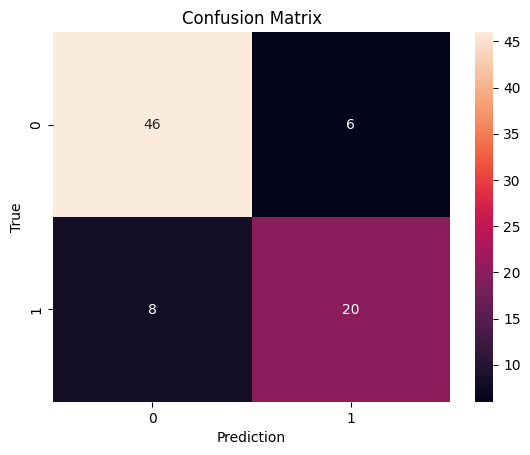

In [22]:
confusion=confusion_matrix(y_test, y_pred)
sns.heatmap(confusion, annot=True)
plt.xlabel('Prediction')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.savefig('knn_conf_matrix.png')
plt.show()

In [23]:
regr.predict([[27, 80000]])

array([0])